Found pure results: /kaggle/input/notebooks/venkatkolluu/05-full-experiment-sweep/experiment_results.csv
Found hybrid results: /kaggle/input/notebooks/venkatkolluu/08-hybrid-comprehensive-final/all_hybrid_final.csv

Pure results: 108 rows
Hybrid results: 15 rows

FULL COMPARISON TABLE (mean F1 | std | collapses out of 3)
                  mean                         std                       \
method            lora   dora    ia3 hybrid   lora   dora    ia3 hybrid   
language budget                                                           
hi       50      0.219  0.221  0.192  0.229  0.042  0.045  0.037  0.054   
         100     0.199  0.199  0.176    NaN  0.056  0.057  0.015    NaN   
         500     0.336  0.330  0.380    NaN  0.053  0.047  0.009    NaN   
         1000    0.204  0.203  0.395    NaN  0.036  0.038  0.063    NaN   
         2000    0.485  0.443  0.491    NaN  0.027  0.062  0.070    NaN   
         20000   0.664  0.666  0.668  0.693  0.012  0.006  0.012  0.003   
te

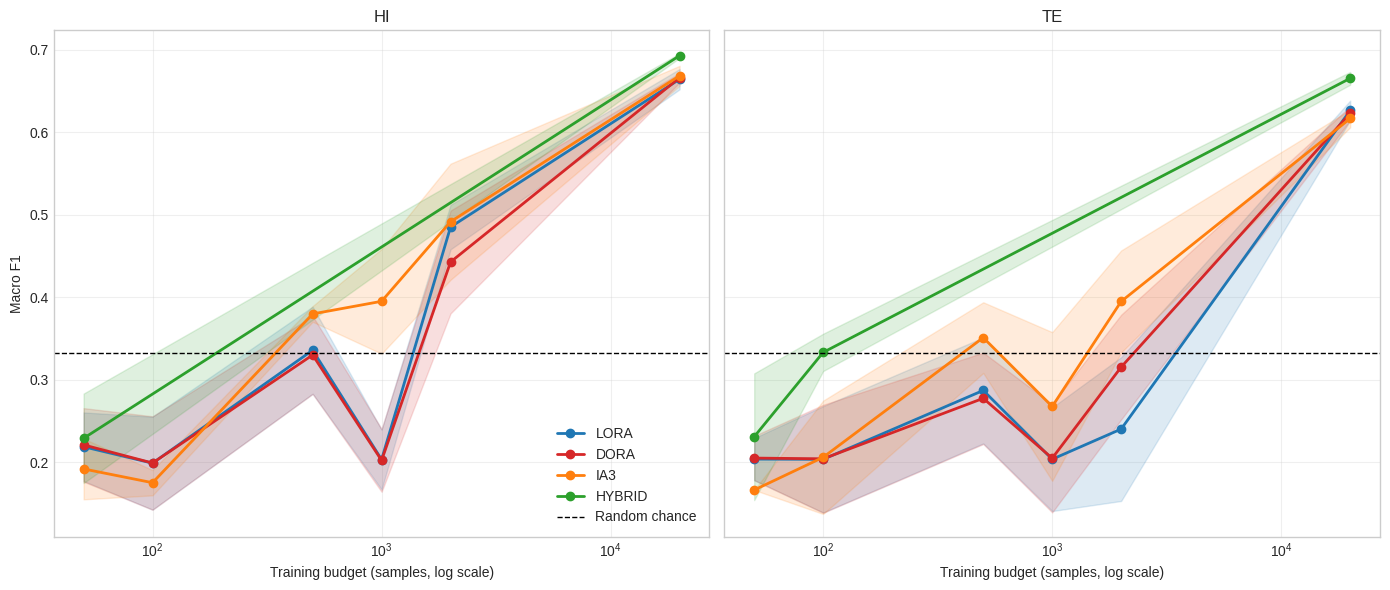

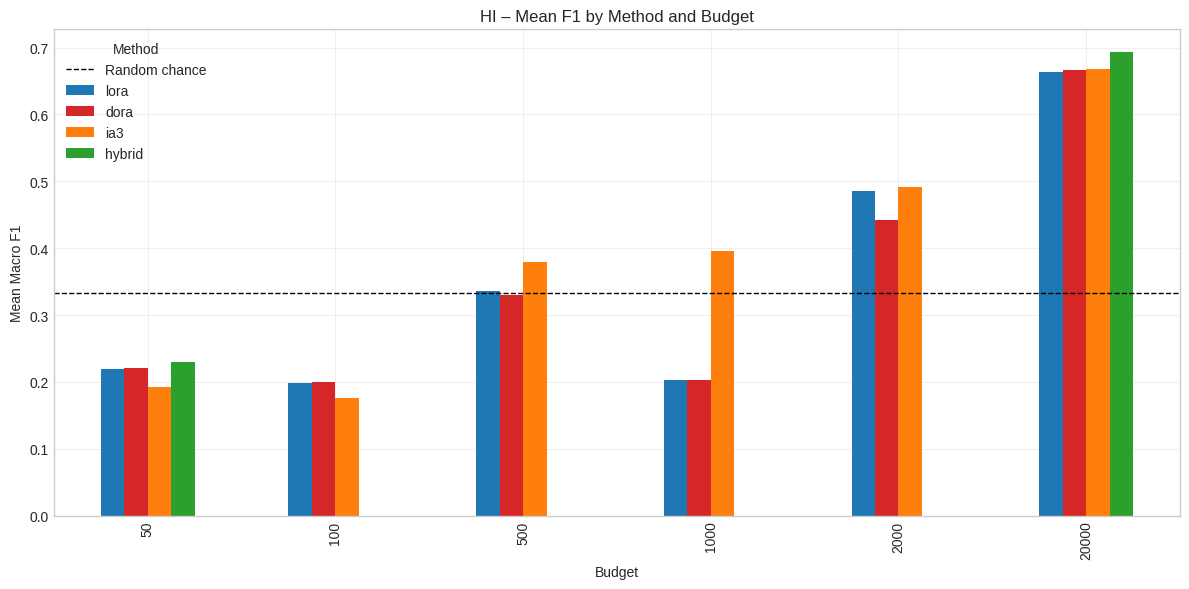

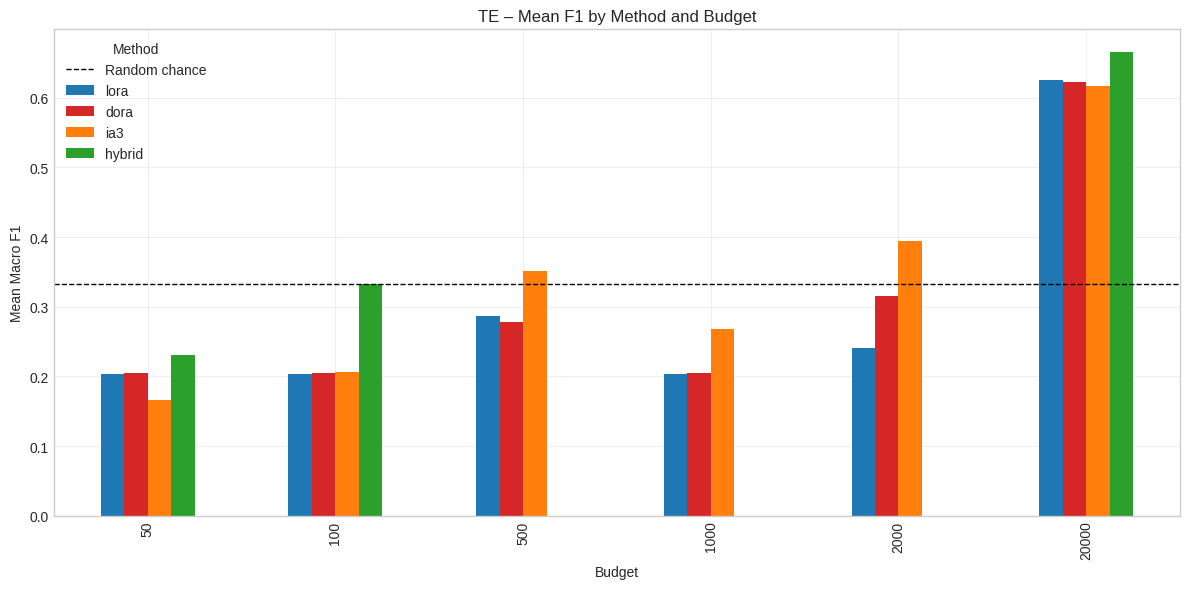

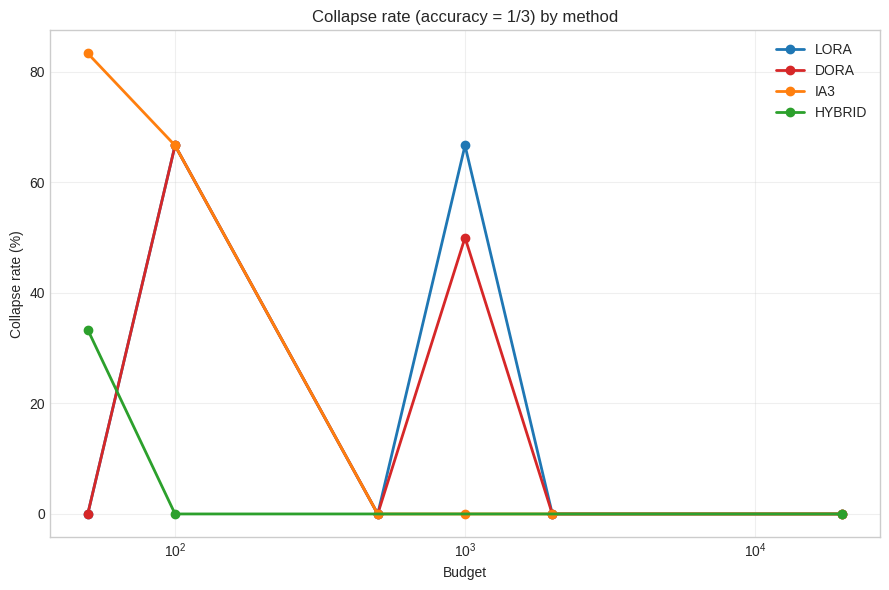

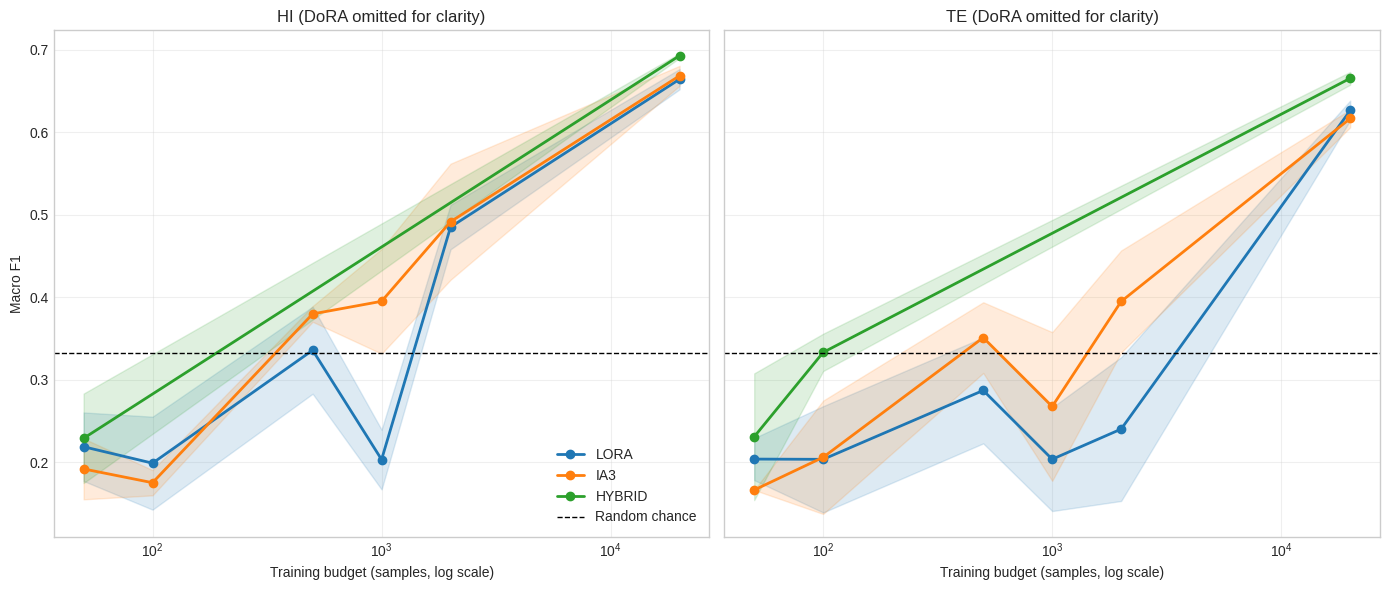


All tables and plots saved to /kaggle/working/
Files:
  - full_comparison_table.csv
  - best_method_per_budget.csv
  - best_f1_values.csv
  - learning_curves_all_methods.png
  - learning_curves_no_dora.png
  - bar_hi_all_methods.png
  - bar_te_all_methods.png
  - collapse_rates_all_methods.png


In [1]:
# ================================
# 09-final-visualization.ipynb
# Final plots and tables for the paper
# Includes LoRA, DoRA, IA³, and Hybrid (IA³+LoRA)
# ================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")

# Colour mapping – ensure all four methods have distinct colours
COLORS = {
    "lora": "#1f77b4",      # blue
    "dora": "#d62728",      # red
    "ia3": "#ff7f0e",       # orange
    "hybrid": "#2ca02c"     # green
}

# ------------------------------
# Recursive file search (handles Kaggle input folders)
# ------------------------------
def find_file_recursive(filename, search_dirs):
    for search_dir in search_dirs:
        if not os.path.exists(search_dir):
            continue
        for root, dirs, files in os.walk(search_dir):
            if filename in files:
                return os.path.join(root, filename)
    return None

# ------------------------------
# Locate pure results (experiment_results.csv) from notebook 05
# ------------------------------
pure_search_dirs = ["/kaggle/input", "/kaggle/working"]
pure_file = find_file_recursive("experiment_results.csv", pure_search_dirs)
if pure_file is None:
    raise FileNotFoundError("experiment_results.csv not found. Please attach output of notebook 05.")
print(f"Found pure results: {pure_file}")
pure_df = pd.read_csv(pure_file)

# ------------------------------
# Locate hybrid results (all_hybrid_final.csv) from notebook 08
# ------------------------------
hybrid_file = find_file_recursive("all_hybrid_final.csv", pure_search_dirs)
if hybrid_file is None:
    raise FileNotFoundError("all_hybrid_final.csv not found. Please attach output of notebook 08.")
print(f"Found hybrid results: {hybrid_file}")
hybrid_df = pd.read_csv(hybrid_file)

# Rename hybrid method to 'hybrid' for consistent naming
hybrid_df["method"] = "hybrid"

print(f"\nPure results: {len(pure_df)} rows")
print(f"Hybrid results: {len(hybrid_df)} rows")

# ------------------------------
# Combine pure (LoRA, DoRA, IA³) and hybrid
# ------------------------------
all_methods = pd.concat([pure_df, hybrid_df], ignore_index=True)

# Ensure method names are consistent
all_methods.loc[all_methods["method"] == "ia3_lora_sequential", "method"] = "hybrid"

# Filter to relevant budgets (50, 100, 500, 1000, 2000, 20000)
budgets = [50, 100, 500, 1000, 2000, 20000]
all_methods = all_methods[all_methods["budget"].isin(budgets)]

# ------------------------------
# Aggregate: mean, std, max, min, collapses per (method, language, budget)
# ------------------------------
def count_collapses(acc):
    # Collapse = accuracy exactly at random chance (0.3333)
    return np.sum(np.isclose(acc, 1/3, atol=0.001))

agg = all_methods.groupby(["method", "language", "budget"]).agg(
    mean_f1=("macro_f1", "mean"),
    std_f1=("macro_f1", "std"),
    max_f1=("macro_f1", "max"),
    min_f1=("macro_f1", "min"),
    collapses=("accuracy", count_collapses),
    n=("seed", "count")
).reset_index()

# ------------------------------
# Pivot tables for mean, std, collapses – includes all four methods
# ------------------------------
# Mean F1
mean_pivot = agg.pivot_table(index=["language", "budget"], columns="method", values="mean_f1").round(3)
# Standard deviation
std_pivot = agg.pivot_table(index=["language", "budget"], columns="method", values="std_f1").round(3)
# Collapse counts
coll_pivot = agg.pivot_table(index=["language", "budget"], columns="method", values="collapses").fillna(0).astype(int)

# Reorder columns to LoRA, DoRA, IA3, Hybrid
desired_order = ["lora", "dora", "ia3", "hybrid"]
# Some methods might be missing if not present; keep only those that exist
existing_order = [m for m in desired_order if m in mean_pivot.columns]
mean_pivot = mean_pivot[existing_order]
std_pivot = std_pivot[existing_order]
coll_pivot = coll_pivot[existing_order]

# Create multi-index columns for the full table
mean_pivot.columns = pd.MultiIndex.from_product([["mean"], mean_pivot.columns])
std_pivot.columns = pd.MultiIndex.from_product([["std"], std_pivot.columns])
coll_pivot.columns = pd.MultiIndex.from_product([["collapses"], coll_pivot.columns])

full_table = pd.concat([mean_pivot, std_pivot, coll_pivot], axis=1)
full_table = full_table.sort_index()

print("\n" + "="*80)
print("FULL COMPARISON TABLE (mean F1 | std | collapses out of 3)")
print("="*80)
print(full_table)

# ------------------------------
# Best method per (language, budget) based on mean F1
# ------------------------------
best_per_cell = agg.loc[agg.groupby(["language", "budget"])["mean_f1"].idxmax()]
best_table = best_per_cell.pivot(index="budget", columns="language", values="method")
best_table_f1 = best_per_cell.pivot(index="budget", columns="language", values="mean_f1").round(3)

print("\n" + "="*80)
print("BEST METHOD PER (LANGUAGE, BUDGET) by MEAN F1")
print("="*80)
print(best_table)
print("\nCORRESPONDING F1 VALUES")
print(best_table_f1)

# ------------------------------
# Save all tables to CSV
# ------------------------------
full_table.to_csv("/kaggle/working/full_comparison_table.csv")
best_table.to_csv("/kaggle/working/best_method_per_budget.csv")
best_table_f1.to_csv("/kaggle/working/best_f1_values.csv")

# ------------------------------
# PLOTS – All four methods shown
# ------------------------------

# 1. Learning curves (F1 vs. budget) – one panel per language
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, lang in zip(axes, ["hi", "te"]):
    for method in existing_order:
        sub = agg[(agg["language"] == lang) & (agg["method"] == method)]
        if sub.empty:
            continue
        sub = sub.sort_values("budget")
        ax.plot(sub["budget"], sub["mean_f1"], marker='o', label=method.upper(),
                color=COLORS.get(method, "gray"), linewidth=2)
        # Confidence band = ±1 std
        ax.fill_between(sub["budget"],
                         sub["mean_f1"] - sub["std_f1"],
                         sub["mean_f1"] + sub["std_f1"],
                         alpha=0.15, color=COLORS.get(method, "gray"))
    ax.set_xscale("log")
    ax.set_xlabel("Training budget (samples, log scale)")
    ax.set_title(f"{lang.upper()}")
    ax.axhline(0.333, color="black", linestyle="--", linewidth=1, label="Random chance")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Macro F1")
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.savefig("/kaggle/working/learning_curves_all_methods.png", dpi=150)
plt.show()

# 2. Bar charts – one per language, showing mean F1 by budget for all methods
for lang in ["hi", "te"]:
    fig, ax = plt.subplots(figsize=(12, 6))
    sub = agg[agg["language"] == lang]
    pivot = sub.pivot(index="budget", columns="method", values="mean_f1")
    # Reorder and select only existing methods
    pivot = pivot[existing_order]
    # Plot as grouped bars
    pivot.plot(kind="bar", ax=ax, color=[COLORS.get(m, "gray") for m in pivot.columns])
    ax.set_xlabel("Budget")
    ax.set_ylabel("Mean Macro F1")
    ax.set_title(f"{lang.upper()} – Mean F1 by Method and Budget")
    ax.axhline(0.333, color="black", linestyle="--", linewidth=1, label="Random chance")
    ax.legend(title="Method")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/bar_{lang}_all_methods.png", dpi=150)
    plt.show()

# 3. Collapse rate plot
collapse_pct = agg.groupby(["method", "budget"]).agg(
    collapse_rate=("collapses", lambda x: np.mean(x) / 3 * 100)
).reset_index()

fig, ax = plt.subplots(figsize=(9, 6))
for method in existing_order:
    sub = collapse_pct[collapse_pct["method"] == method]
    if sub.empty:
        continue
    ax.plot(sub["budget"], sub["collapse_rate"], marker='o', label=method.upper(),
            color=COLORS.get(method, "gray"), linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("Budget")
ax.set_ylabel("Collapse rate (%)")
ax.set_title("Collapse rate (accuracy = 1/3) by method")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/collapse_rates_all_methods.png", dpi=150)
plt.show()

# ------------------------------
# Additional plot: Learning curves with DoRA omitted for clarity
# (optional – to avoid visual clutter in the main figure)
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
# Use only LoRA, IA3, Hybrid (drop DoRA if present)
clean_methods = [m for m in ["lora", "ia3", "hybrid"] if m in existing_order]
for ax, lang in zip(axes, ["hi", "te"]):
    for method in clean_methods:
        sub = agg[(agg["language"] == lang) & (agg["method"] == method)]
        if sub.empty:
            continue
        sub = sub.sort_values("budget")
        ax.plot(sub["budget"], sub["mean_f1"], marker='o', label=method.upper(),
                color=COLORS.get(method, "gray"), linewidth=2)
        ax.fill_between(sub["budget"],
                         sub["mean_f1"] - sub["std_f1"],
                         sub["mean_f1"] + sub["std_f1"],
                         alpha=0.15, color=COLORS.get(method, "gray"))
    ax.set_xscale("log")
    ax.set_xlabel("Training budget (samples, log scale)")
    ax.set_title(f"{lang.upper()} (DoRA omitted for clarity)")
    ax.axhline(0.333, color="black", linestyle="--", linewidth=1, label="Random chance")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Macro F1")
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.savefig("/kaggle/working/learning_curves_no_dora.png", dpi=150)
plt.show()

print("\nAll tables and plots saved to /kaggle/working/")
print("Files:")
print("  - full_comparison_table.csv")
print("  - best_method_per_budget.csv")
print("  - best_f1_values.csv")
print("  - learning_curves_all_methods.png")
print("  - learning_curves_no_dora.png")
print("  - bar_hi_all_methods.png")
print("  - bar_te_all_methods.png")
print("  - collapse_rates_all_methods.png")